In [43]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import Add
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Layer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [44]:
#Leitura dos dados e criação das features derivadas

dados = pd.read_parquet("drive/MyDrive/ProjetoFinal/petr4.parquet")
dados["time_date"] = pd.to_datetime(dados["time"], unit='s')
dados["return_1"] = dados["close"].pct_change()
dados["return_5"] = dados["close"].pct_change(5)
dados["return_10"] = dados["close"].pct_change(10)
dados["volatility"] = dados["return_1"].rolling(20).std()
dados["hour"] = dados["time_date"].dt.hour
dados["hour_sin"] = np.sin(2*np.pi*dados["hour"]/24)
dados["hour_cos"] = np.cos(2*np.pi*dados["hour"]/24)
dados["ema9"] = dados["close"].ewm(span=9).mean()
dados["ema21"] = dados["close"].ewm(span=21).mean()

delta = dados["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
dados["rsi"] = 100 - (100 / (1 + rs))

dados = dados.dropna()
dados

,time,open,high,low,close,tick_volume,spread,real_volume,time_date,return_1,return_5,return_10,volatility,hour,hour_sin,hour_cos,ema9,ema21,rsi
20,1609772400,11.17,11.20,11.15,11.19,2742,1,1153400,2021-01-04 15:00:00,0.001791,-0.000893,-0.009735,0.003754,15,-0.707107,-0.707107,11.195210,11.219015,31.578947
21,1609773300,11.20,11.24,11.18,11.24,3641,1,2106000,2021-01-04 15:15:00,0.004468,0.003571,0.002676,0.003869,15,-0.707107,-0.707107,11.204235,11.221190,36.585366
22,1609774200,11.24,11.24,11.22,11.23,2012,1,1151700,2021-01-04 15:30:00,-0.000890,0.005372,0.000891,0.003164,15,-0.707107,-0.707107,11.209419,11.222092,37.500000
23,1609775100,11.22,11.25,11.22,11.24,2229,1,844500,2021-01-04 15:45:00,0.000890,0.008977,0.003571,0.003116,15,-0.707107,-0.707107,11.215564,11.223904,35.897436
24,1609776000,11.24,11.26,11.22,11.24,2465,1,1039200,2021-01-04 16:00:00,0.000000,0.006267,0.001783,0.002852,16,-0.866025,-0.500000,11.220470,11.225516,41.176471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21306,1698768000,34.76,34.79,34.65,34.67,1828,1,810300,2023-10-31 16:00:00,-0.002589,-0.003449,-0.002876,0.002219,16,-0.866025,-0.500000,34.718845,34.780147,39.473684
21307,1698768900,34.67,34.69,34.57,34.68,2118,1,1483100,2023-10-31 16:15:00,0.000288,-0.001152,-0.003162,0.001714,16,-0.866025,-0.500000,34.711076,34.771043,38.666667
21308,1698769800,34.68,34.75,34.63,34.73,2665,1,1649300,2023-10-31 16:30:00,0.001442,0.002598,0.001731,0.001738,16,-0.866025,-0.500000,34.714861,34.767312,47.222222
21309,1698770700,34.73,34.79,34.68,34.73,1723,1,1493800,2023-10-31 16:45:00,0.000000,0.001442,0.001153,0.001722,16,-0.866025,-0.500000,34.717889,34.763920,48.571429


In [45]:
#Criação da lista de features

features = [
    "close",
    "real_volume",
    "return_1",
    "ema9",
    "ema21",
    "volatility",
    "hour_sin",
    "hour_cos"
]

data = dados[features].values

In [46]:
#Normalização dos dados

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [47]:
# Definição das variáveis de janela de dias usadas na predição, como são utilizados intervalos de 15 minutos para os dados, então cada dia completo de pregão correspodem as 28 candles.
# A cada conjunto de 5 dias de entrada é realizada a predição de 1 dia completo.

candles_day = 28
input_window = candles_day * 5
output_window = candles_day
test_size = candles_day * 30

# Criação dos conjuntos de treino e de teste

x_train = []
y_train = []

for i in range(input_window, len(scaled_data)-test_size-output_window):
    x_train.append(scaled_data[i-input_window:i])
    y_train.append(scaled_data[i:i+output_window,0])

x_test = []
y_test = []

for i in range(len(scaled_data)-test_size, len(scaled_data)-output_window):
    x_test.append(scaled_data[i-input_window:i])
    y_test.append(scaled_data[i:i+output_window,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_test = np.array(x_test)
y_test = np.array(y_test)


In [48]:
#Criação das features de tempo para fornecer de entrada para o método Time2Vec

def create_time_features(n_samples, timesteps):

    time = np.tile(np.arange(timesteps), (n_samples,1))
    time = np.expand_dims(time, axis=-1)
    time = time / timesteps

    return time

time_train = create_time_features(x_train.shape[0], input_window)
time_test = create_time_features(x_test.shape[0], input_window)

In [49]:
#Camada personalizada Time2Vec que aprende uma representação temporal

class Time2Vec(Layer):

    def __init__(self, kernel_size):

        super().__init__()

        self.k = kernel_size

    def build(self, input_shape):

        self.wb = self.add_weight(
            shape=(1,),
            initializer="uniform",
            trainable=True
        )

        self.bb = self.add_weight(
            shape=(1,),
            initializer="uniform",
            trainable=True
        )

        self.wa = self.add_weight(
            shape=(1,self.k-1),
            initializer="uniform",
            trainable=True
        )

        self.ba = self.add_weight(
            shape=(1,self.k-1),
            initializer="uniform",
            trainable=True
        )

    def call(self, inputs):

        bias = self.wb * inputs + self.bb
        periodic = tf.math.sin(tf.matmul(inputs,self.wa) + self.ba)

        return tf.concat([bias, periodic], axis=-1)

In [50]:
#Definição do encoder do transformer

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    # Self attention
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward
    y = Dense(ff_dim, activation="relu")(x)
    y = Dropout(dropout)(y)
    y = Dense(inputs.shape[-1])(y)

    out = Add()([x, y])
    out = LayerNormalization(epsilon=1e-6)(out)

    return out

In [51]:
#Definição do transformer, com suas camadas, e inclusão Time2Vec

def build_transformer(input_window, n_features):

    feature_input = Input(shape=(input_window, n_features))
    time_input = Input(shape=(input_window,1))

    time_embedding = Time2Vec(8)(time_input)

    x = Concatenate(axis=-1)([feature_input, time_embedding])

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.2
    )

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.2
    )

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(output_window)(x)

    model = Model([feature_input, time_input], outputs)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [52]:
#Construção do transformer

model = build_transformer(
    input_window,
    x_train.shape[2]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 140, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 140, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec_2         │ (None, 140, 8)    │         16 │ input_layer_5[0]… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 140, 16)   │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ time2_vec_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 140, 16)   │     17,168 │ concatenate_2[0]… │
│ (MultiHeadAttentio… │                   │            │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 140, 16)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 140, 16)   │          0 │ dropout_15[0][0], │
│                     │                   │            │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 140, 16)   │         32 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 140, 128)  │      2,176 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 140, 128)  │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 140, 16)   │      2,064 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 140, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 140, 16)   │         32 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 140, 16)   │     17,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 140, 16)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 140, 16)   │          0 │ dropout_18[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 140, 16)   │         32 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 45,868 (179.17 KB)

 Trainable params: 45,868 (179.17 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
#Treinando o modelo

history = model.fit(
    [x_train, time_train],
    y_train,
    validation_data=([x_test, time_test], y_test),
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 235s 359ms/step - loss: 0.0116 - mae: 0.0631 - val_loss: 0.0019 - val_mae: 0.0341
Epoch 2/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 225s 355ms/step - loss: 0.0025 - mae: 0.0344 - val_loss: 0.0023 - val_mae: 0.0378
Epoch 3/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 226s 357ms/step - loss: 0.0017 - mae: 0.0296 - val_loss: 0.0026 - val_mae: 0.0396
Epoch 4/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 220s 346ms/step - loss: 0.0016 - mae: 0.0288 - val_loss: 0.0020 - val_mae: 0.0350
Epoch 5/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 225s 356ms/step - loss: 0.0015 - mae: 0.0283 - val_loss: 0.0016 - val_mae: 0.0341
Epoch 6/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 259s 352ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0015 - val_mae: 0.0315
Epoch 7/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 223s 353ms/step - loss: 0.0013 - mae: 0.0263 - val_loss: 0.0011 - val_mae: 0.0261
Epoch 8/40
634/634 ━━━━━━━━━━━━━━━━━━━━ 218s 344ms/step - loss: 0.0010 - mae: 0.0236 - val_loss: 0.0018 - val_mae: 0.0351
Epoch 9/40
634/634 ━━━━━

In [54]:
#Função para reverter a normalização dos dados e recuperar os dados conjunto de origem.

def inverse_close_scaling(data, scaler):

    close_min = scaler.data_min_[0]
    close_max = scaler.data_max_[0]

    return data * (close_max - close_min) + close_min

In [55]:
#Rodando o modelo no conjunto de teste.

predictions = model.predict([x_test, time_test])

predictions_rescaled = inverse_close_scaling(predictions, scaler)
y_test_rescaled = inverse_close_scaling(y_test, scaler)

pred_series = predictions_rescaled[:,0]
real_series = y_test_rescaled[:,0]

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step


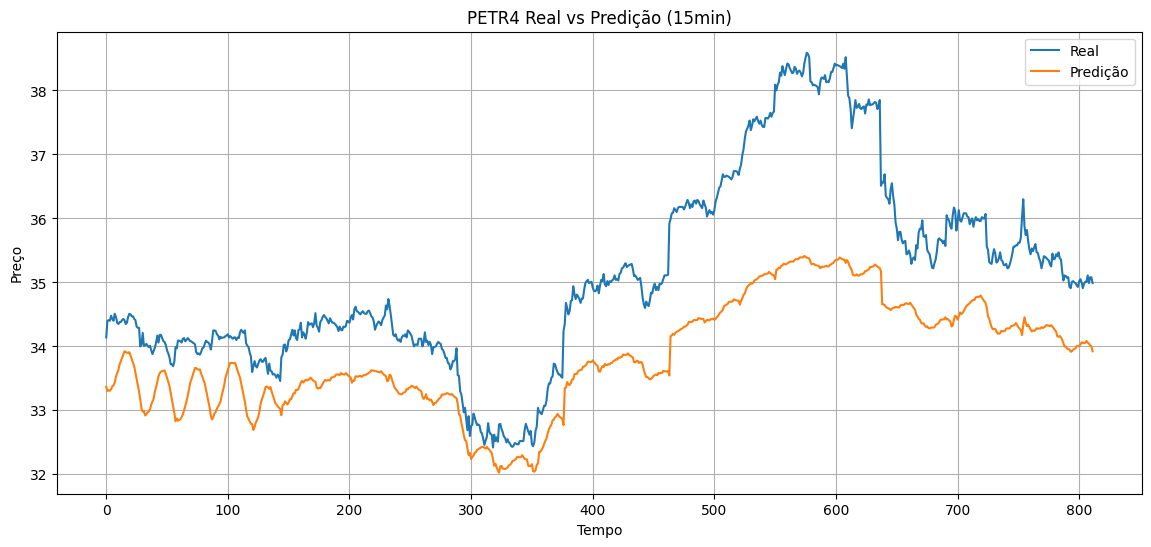

In [56]:
#Gráfico de comparação dos dados reais e os valores de predição, cosidernado somente o primeiro candle previsto para cada conjunto de entrada.

plt.figure(figsize=(14,6))

plt.plot(real_series, label="Real")
plt.plot(pred_series, label="Predição")

plt.title("PETR4 Real vs Predição (15min)")
plt.xlabel("Tempo")
plt.ylabel("Preço")

plt.legend()
plt.grid()

plt.show()

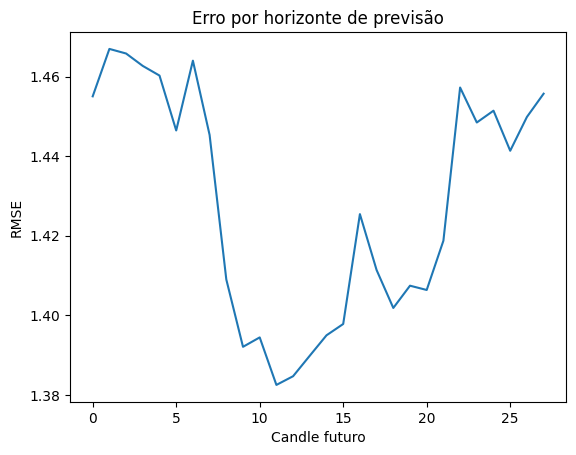

In [57]:
#Gráfico mostrando a evolução dos erros por horizonte de previsão, ou seja, ao longo do 28 candels, esse modelo mostrou um resultado muito instável, com erros de previsão muito altos já a partir do primeiro candle previsto.
errors = []

for i in range(28):

    e = np.sqrt(mean_squared_error(
        y_test_rescaled[:,i],
        predictions_rescaled[:,i]
    ))

    errors.append(e)

plt.plot(errors)

plt.title("Erro por horizonte de previsão")
plt.xlabel("Candle futuro")
plt.ylabel("RMSE")

plt.show()

In [58]:
#Principais métricas para avaliação da eficácia do modelo.

mae = mean_absolute_error(real_series, pred_series)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(real_series, pred_series))
print("RMSE:", rmse)

mape = np.mean(np.abs((real_series - pred_series) / real_series))
print("MAPE:", mape)

real = real_series
pred = pred_series
real_direction = np.sign(np.diff(real))
pred_direction = np.sign(np.diff(pred))
accuracy = np.mean(real_direction == pred_direction)
print("Acurácia direcional:", accuracy)

ic = np.corrcoef(pred_series[:-1], real_series[1:])[0,1]
print("Coeficiente de Informação:", ic)

MAE: 1.257429984304413
RMSE: 1.4550328141161146
MAPE: 0.035061533896782175
Acurácia direcional: 0.46732429099876693
Coeficiente de Informação: 0.9599855217698926
